In [ ]:
import pandas as pd

# Load the data from the provided Excel file
file_path = '/content/Lenskart Brand Perception Survey (Responses).xlsx'
data = pd.read_excel(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()

,Timestamp,Score,What is your age group?,What is your gender?,Which of the following Eyewear products do you use?,How often do you purchase eye products?,"While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Affordability]","While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Quality]","While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Fashion]","While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Delivery time]",...,Do you have a Lenskart Gold Membership,Have you tried the Lenskart's Virtual Try On or at Home Try On feature ?,How important are deals and discounts while making an Eyewear purchase? (Select one),"If Lenskart raised its prices, would you switch to another brand?","How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [Lenskart]","How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [TitanEye+]","How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [GKB Optics]","How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [Ray Ban]","How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [Local Brands]",Column 50
0,2025-02-24 13:44:43.947,0,35 - 44,Female,"Sunglasses, Anti-Reflective Lenses",2 years,5,4,4,3,...,Yes,Yes,Slightly Important,Yes,5,4,3,4,4,NaN
1,2025-02-24 13:46:33.259,0,25 - 34,Female,"Powered Glasses, Sunglasses, Anti-Reflective L...",1 year,4,5,4,5,...,Yes,Yes,Most Important,No,5,2,4,4,3,NaN
2,2025-02-24 13:49:43.237,0,18 - 24,Male,"Powered Glasses, Sunglasses",1 year,5,5,4,5,...,Yes,Yes,Most Important,Depends on the price increase,5,3,5,3,4,NaN
3,2025-02-24 13:52:20.071,0,18 - 24,Male,"Powered Glasses, Sunglasses",1 year,3,4,4,2,...,Yes,Yes,Slightly Important,Depends on the price increase,5,4,3,5,1,NaN
4,2025-02-24 13:53:19.451,0,18 - 24,Female,Sunglasses,2 years,3,4,4,4,...,No,No,Most Important,Depends on the price increase,4,4,3,4,3,NaN


In [ ]:
# Check for missing values and data types
missing_data = data.isnull().sum()
data_types = data.dtypes

missing_data, data_types

(Timestamp                                                                                                                                0
 Score                                                                                                                                    0
 What is your age group?                                                                                                                  0
 What is your gender?                                                                                                                     0
 Which of the following Eyewear products do you use?                                                                                      0
 How often do you purchase eye products?                                                                                                  0
 While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Affordability]         0
 While purchasing ey

In [ ]:
# Remove the unnecessary column 'Column 50'
data_cleaned = data.drop(columns=['Column 50'])

# Feature Engineering
# 1. Aggregate Brand Ratings: Calculate the mean rating across all brand-related questions for a simple aggregate score
brand_columns = [col for col in data.columns if "How likely are you to recommend each of these brands" in col]
data_cleaned['Average_Brand_Rating'] = data[brand_columns].mean(axis=1)

# 2. Create Demographic Segments: Combine age group and gender into a single column
data_cleaned['Demographic_Segment'] = data_cleaned['What is your age group?'] + " - " + data_cleaned['What is your gender?']

# Show the new columns and the cleaned-up dataset head to confirm changes
data_cleaned[['Average_Brand_Rating', 'Demographic_Segment']].head(), data_cleaned.head()


(   Average_Brand_Rating Demographic_Segment
 0                   4.0    35 - 44 - Female
 1                   3.6    25 - 34 - Female
 2                   4.0      18 - 24 - Male
 3                   3.6      18 - 24 - Male
 4                   3.6    18 - 24 - Female,
                 Timestamp  Score What is your age group? What is your gender?  \
 0 2025-02-24 13:44:43.947      0                 35 - 44               Female   
 1 2025-02-24 13:46:33.259      0                 25 - 34               Female   
 2 2025-02-24 13:49:43.237      0                 18 - 24                 Male   
 3 2025-02-24 13:52:20.071      0                 18 - 24                 Male   
 4 2025-02-24 13:53:19.451      0                 18 - 24               Female   
 
   Which of the following Eyewear products do you use?  \
 0                 Sunglasses, Anti-Reflective Lenses    
 1  Powered Glasses, Sunglasses, Anti-Reflective L...    
 2                        Powered Glasses, Sunglasses    
 3 

## **SEGMENTATION ANALYSIS**

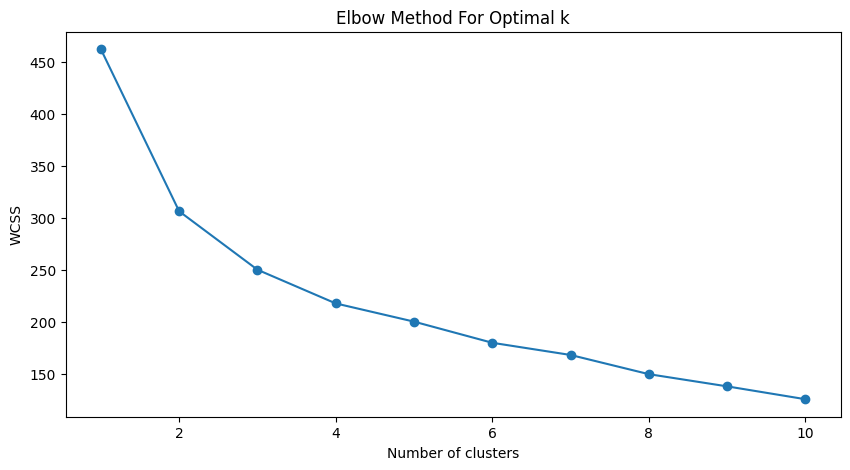

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Selecting relevant variables for clustering
# Using demographic segment and the average brand rating as examples. We'll include factors influencing purchasing decisions.
factors_columns = [col for col in data.columns if "While purchasing eyewear, how likely does each factor influence your decision" in col]
cluster_data = data_cleaned[factors_columns + ['Average_Brand_Rating']]

# Standardizing the data
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# Determining the optimal number of clusters using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(cluster_data_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the results of the Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS') # Within cluster sum of squares
plt.show()


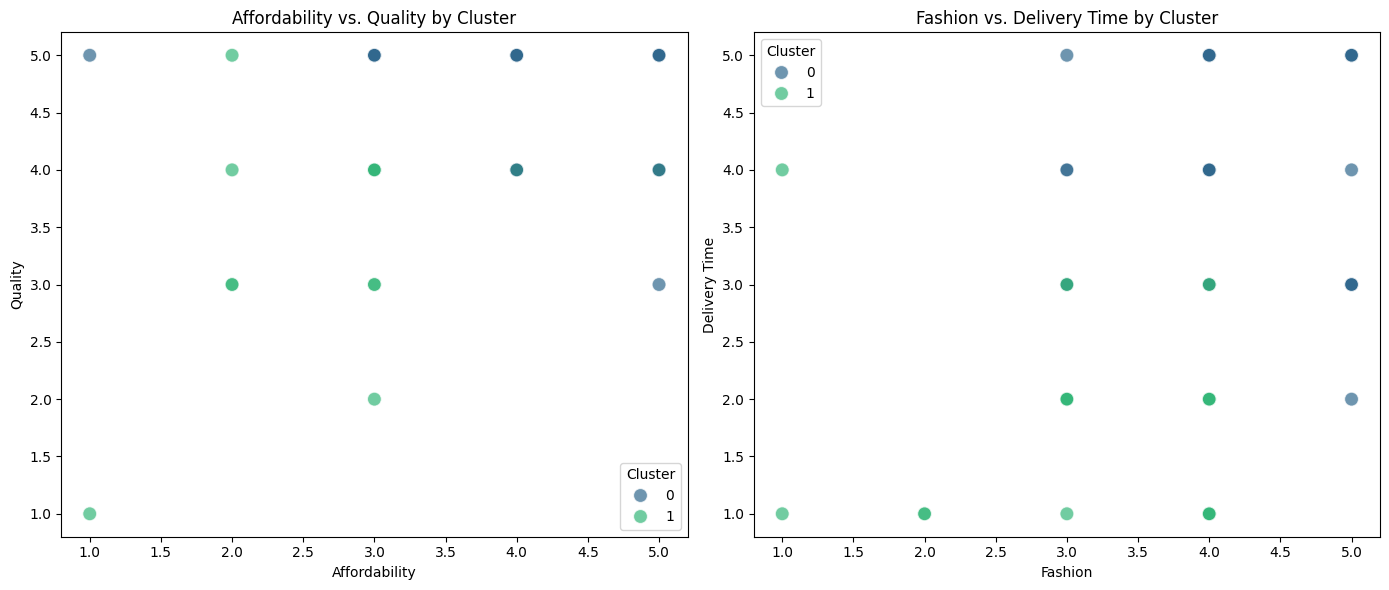

In [ ]:
import seaborn as sns

# Setting up the plot with seaborn
plt.figure(figsize=(14, 6))

# Plot 1: Affordability vs. Quality
plt.subplot(1, 2, 1)
sns.scatterplot(x=data_cleaned['While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Affordability]'],
                y=data_cleaned['While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Quality]'],
                hue=data_cleaned['Cluster'], palette='viridis', s=100, alpha=0.7)
plt.title('Affordability vs. Quality by Cluster')
plt.xlabel('Affordability')
plt.ylabel('Quality')

# Plot 2: Fashion vs. Delivery Time
plt.subplot(1, 2, 2)
sns.scatterplot(x=data_cleaned['While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Fashion]'],
                y=data_cleaned['While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Delivery time]'],
                hue=data_cleaned['Cluster'], palette='viridis', s=100, alpha=0.7)
plt.title('Fashion vs. Delivery Time by Cluster')
plt.xlabel('Fashion')
plt.ylabel('Delivery Time')

plt.tight_layout()
plt.show()


In [ ]:
# Print all column names to verify the correct ones for plotting
print(data.columns)


Index(['Timestamp', 'Score', 'What is your age group?', 'What is your gender?',
       'Which of the following Eyewear products do you use?',
       'How often do you purchase eye products?',
       'While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Affordability]',
       'While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Quality]',
       'While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Fashion]',
       'While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Delivery time]',
       'While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Buying experience]',
       'Have you heard about Lenskart before ?',
       'Where did you first learn about Lenskart?',
       'How would yo

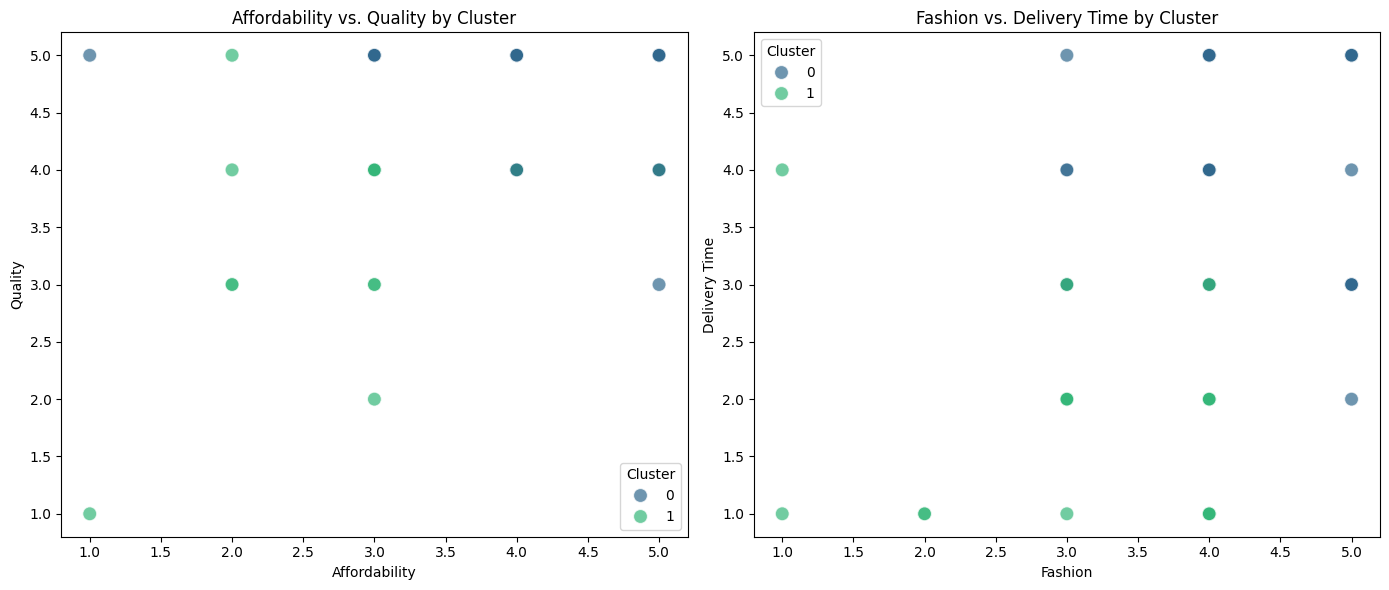

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
data = pd.read_excel('/content/Lenskart Brand Perception Survey (Responses).xlsx')

# Assuming brand rating columns are named appropriately
brand_columns = [col for col in data.columns if "How likely are you to recommend each of these brands" in col]
data['Average_Brand_Rating'] = data[brand_columns].mean(axis=1)

# Standardizing the data
factors_columns = [col for col in data.columns if "While purchasing eyewear, how likely does each factor influence your decision" in col]
cluster_data = data[factors_columns + ['Average_Brand_Rating']]
scaler = StandardScaler()
cluster_data_scaled = scaler.fit_transform(cluster_data)

# K-means Clustering
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=0)
cluster_labels = kmeans.fit_predict(cluster_data_scaled)
data['Cluster'] = cluster_labels

# Analysis of clusters: ensure only numeric columns are involved in mean calculation
numeric_cols = data.select_dtypes(include=[np.number]).columns
cluster_summary = data.groupby('Cluster')[numeric_cols].mean()

# Visualization: Make sure to reference numeric columns appropriately
# Visualization: Update with the correct column names
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(
    x='While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Affordability]',
    y='While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Quality]',
    data=data,
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Affordability vs. Quality by Cluster')
plt.xlabel('Affordability')
plt.ylabel('Quality')

plt.subplot(1, 2, 2)
sns.scatterplot(
    x='While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Fashion]',
    y='While purchasing eyewear, how likely does each factor influence your decision? (1 = Not likely, 5 = Most likely) [Delivery time]',
    data=data,
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Fashion vs. Delivery Time by Cluster')
plt.xlabel('Fashion')
plt.ylabel('Delivery Time')

plt.tight_layout()
plt.show()



## **POSITIONING ANALYSIS**

In [ ]:
import pandas as pd

# Load the data from the provided Excel file
file_path = '/content/Lenskart Brand Perception Survey (Responses).xlsx'
data = pd.read_excel(file_path)

# Extracting relevant data for positioning analysis
# Assuming the columns for overall perception and price-to-value ratio as indicators of quality and affordability respectively
quality_columns = [col for col in data.columns if "How would you rate the quality of eyewear from these brands" in col]
price_value_columns = [col for col in data.columns if "How do you rate the price-to-value ratio of these brands" in col]

# Creating a DataFrame for perceptual mapping
quality_ratings = data[quality_columns].mean()
price_value_ratings = data[price_value_columns].mean()

# Creating a new DataFrame for easier plotting
positioning_data = pd.DataFrame({
    'Brand': ['Lenskart', 'TitanEye+', 'GKB Optics', 'Ray Ban', 'Local Brands'],
    'Quality': [quality_ratings[col] for col in quality_columns],
    'Price_to_Value': [price_value_ratings[col] for col in price_value_columns]
})

positioning_data


,Brand,Quality,Price_to_Value
0,Lenskart,4.103896,4.051948
1,TitanEye+,3.935065,3.571429
2,GKB Optics,3.168831,3.142857
3,Ray Ban,4.298701,3.454545
4,Local Brands,3.025974,3.519481


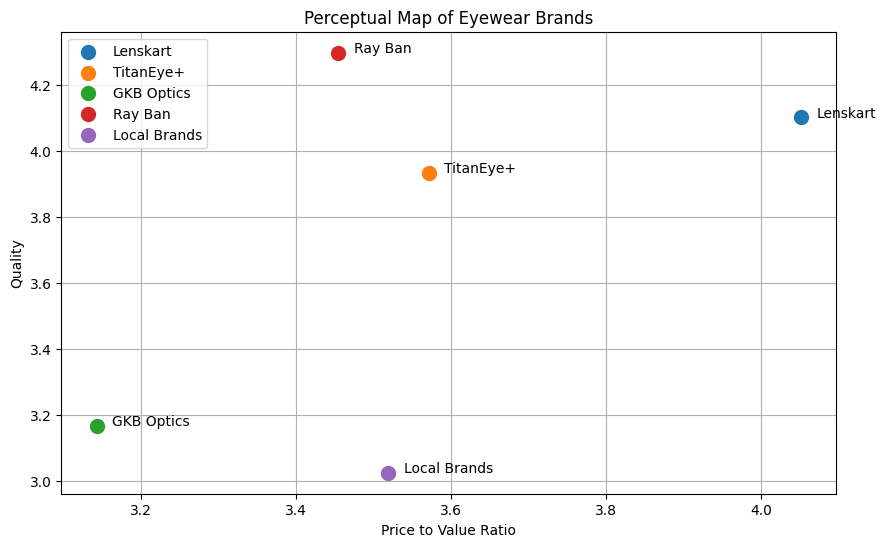

In [ ]:
import matplotlib.pyplot as plt

# Creating a scatter plot for perceptual mapping
plt.figure(figsize=(10, 6))
for i, row in positioning_data.iterrows():
    plt.scatter(row['Price_to_Value'], row['Quality'], label=row['Brand'], s=100)
    plt.text(row['Price_to_Value'] + 0.02, row['Quality'], row['Brand'])

plt.title('Perceptual Map of Eyewear Brands')
plt.xlabel('Price to Value Ratio')
plt.ylabel('Quality')
plt.grid(True)
plt.legend()
plt.show()


## **COJOINT ANALYSIS**


In [ ]:
import statsmodels.api as sm

# For the purpose of this example, let's use the following columns if they match the quality and price-to-value ratings:
quality_rating_lenskart = 'How would you rate the quality of eyewear from these brands? (1 = Poor, 5 = Excellent) [Lenskart]'
price_value_rating_lenskart = 'How do you rate the price-to-value ratio of these brands? (1 = Poor Value, 5 = Excellent Value) [Lenskart]'

# Using 'How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [Lenskart]' as the dependent variable
recommendation_likelihood = 'How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [Lenskart]'

# Selecting the independent variables for the model
X = data[[quality_rating_lenskart, price_value_rating_lenskart]]
X = sm.add_constant(X)  # adding a constant for the intercept

# Dependent variable
y = data[recommendation_likelihood]

# Fit the regression model
model = sm.OLS(y, X).fit()

# Get the summary of the regression
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                                                         OLS Regression Results                                                                         
========================================================================================================================================================================
Dep. Variable:     How likely are you to recommend each of these brands to a friend? (1 = Unlikely, 5 = Very Likely) [Lenskart]   R-squared:                       0.565
Model:                                                                                                                      OLS   Adj. R-squared:                  0.554
Method:                                                                                                           Least Squares   F-statistic:                     48.13
Date:                                                                                                          Tue, 25 Feb 2025   Prob (F-statistic):           4.08e-14
Time:                                                                                                                  22:31:56   Log-Likelihood:                -72.230
No. Observations:                                                                                                            77   AIC:                             150.5
Df Residuals:                                                                                                                74   BIC:                             157.5
Df Model:                                                                                                                     2                                         
Covariance Type:                                                                                                      nonrobust                                         
==============================================================================================================================================================================
                                                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
const                                                                                                          0.5969      0.383      1.559      0.123      -0.166       1.360
How would you rate the quality of eyewear from these brands? (1 = Poor, 5 = Excellent) [Lenskart]              0.5544      0.096      5.757      0.000       0.363       0.746
How do you rate the price-to-value ratio of these brands? (1 = Poor Value, 5 = Excellent Value) [Lenskart]     0.3488      0.087      4.002      0.000       0.175       0.523
==============================================================================
Omnibus:                        6.526   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.038   Jarque-Bera (JB):                7.283
Skew:                          -0.400   Prob(JB):                       0.0262
Kurtosis:                       4.277   Cond. No.                         32.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""